# 🔬 Enhancing Glaucoma Detection Using Machine Learning
### Ensemble of VGG19, ResNet101 & MobileNetV2
### 📦 Dataset: ACRIMA (Real Fundus Images — 705 images)

> **Runtime:** Go to `Runtime → Change Runtime Type → T4 GPU` before running!

## 1️⃣ Setup & Install Dependencies

In [16]:
# Install required libraries
!pip install -q gdown scikit-learn seaborn matplotlib opencv-python-headless
!pip install -q tensorflow==2.15.0

import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from glob import glob
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              accuracy_score, precision_score,
                              recall_score, f1_score)

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG19, ResNet101, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import RMSprop

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Constants
IMAGE_SIZE    = (224, 224)
BATCH_SIZE    = 16
EPOCHS        = 30
NUM_CLASSES   = 2
LEARNING_RATE = 1e-4

print(f'✅ TensorFlow {tf.__version__}')
print(f'✅ GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print('✅ All libraries loaded successfully')

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
✅ TensorFlow 2.20.0
✅ GPU available: True
✅ All libraries loaded successfully


## 2️⃣ Mount Google Drive

In [17]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR  = '/content/drive/MyDrive/GlaucomaProject'
MODEL_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'📁 Model save directory: {MODEL_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Model save directory: /content/drive/MyDrive/GlaucomaProject/models


## 3️⃣ Download ACRIMA Dataset

In [18]:
import gdown

ACRIMA_DIR = '/content/ACRIMA'

if not os.path.exists(ACRIMA_DIR) or len(os.listdir(ACRIMA_DIR)) == 0:
    print('📥 Downloading ACRIMA dataset...')
    try:
        # Primary method: folder download
        gdown.download_folder(
            'https://drive.google.com/drive/folders/1zXM6cZBZIKrXDwN0QBcRCeKf3_GFJa2X',
            output=ACRIMA_DIR,
            quiet=False
        )
    except Exception as e:
        print(f'⚠️  Folder download failed: {e}')
        print('🔄 Trying fallback zip download...')
        gdown.download(
            'https://drive.google.com/uc?id=1zXM6cZBZIKrXDwN0QBcRCeKf3_GFJa2X',
            '/content/ACRIMA.zip',
            quiet=False
        )
        !unzip -q /content/ACRIMA.zip -d /content/ACRIMA
    print('✅ Download complete!')
else:
    print('✅ ACRIMA already downloaded, skipping.')

# Inspect folder structure
print('\n📂 Folder structure:')
for root, dirs, files in os.walk(ACRIMA_DIR):
    level = root.replace(ACRIMA_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        subindent = '  ' * (level + 1)
        img_count = len([f for f in files if f.lower().endswith(('.jpg','.png','.jpeg'))])
        if img_count > 0:
            print(f'{subindent}→ {img_count} images')

✅ ACRIMA already downloaded, skipping.

📂 Folder structure:
ACRIMA/
  Training_Set/
    Training_Set/
      Training/
  Evaluation_Set/
    Evaluation_Set/
      Validation/
  Test_Set/
    Test_Set/
      Test/


In [19]:
# ── Auto-detect ACRIMA folder structure ───────────────────────────────────────
# ACRIMA can have slightly different subfolder names depending on download source.
# This cell auto-detects the correct paths.

def find_class_dirs(base):
    """Walk base and find directories that contain image files."""
    class_dirs = {}
    for root, dirs, files in os.walk(base):
        imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if len(imgs) > 10:  # must have meaningful number of images
            folder_name = os.path.basename(root).lower()
            if any(k in folder_name for k in ['glaucom', 'positive', 'pos', 'g_']):
                class_dirs['glaucoma'] = root
            elif any(k in folder_name for k in ['normal', 'non', 'negative', 'neg', 'n_', 'healthy']):
                class_dirs['normal'] = root
    return class_dirs

class_dirs = find_class_dirs(ACRIMA_DIR)

# If auto-detect fails, set manually based on what you see above
if 'glaucoma' not in class_dirs or 'normal' not in class_dirs:
    print('⚠️  Auto-detect failed. Please set paths manually below.')
    # EDIT THESE if needed based on the folder structure printed above:
    class_dirs['glaucoma'] = '/content/ACRIMA/Images/Glaucomatous'
    class_dirs['normal']   = '/content/ACRIMA/Images/Non-Glaucomatous'

GLAUCOMA_DIR = class_dirs['glaucoma']
NORMAL_DIR   = class_dirs['normal']

print(f'✅ Glaucoma folder : {GLAUCOMA_DIR}')
print(f'✅ Normal folder   : {NORMAL_DIR}')
print(f'   Glaucoma images : {len(glob(GLAUCOMA_DIR+"/*.jpg") + glob(GLAUCOMA_DIR+"/*.png"))}')
print(f'   Normal images   : {len(glob(NORMAL_DIR+"/*.jpg") + glob(NORMAL_DIR+"/*.png"))}')

⚠️  Auto-detect failed. Please set paths manually below.
✅ Glaucoma folder : /content/ACRIMA/Images/Glaucomatous
✅ Normal folder   : /content/ACRIMA/Images/Non-Glaucomatous
   Glaucoma images : 0
   Normal images   : 0


In [20]:
# ALTERNATIVE: Download ACRIMA from Kaggle
# Step 1: Upload your kaggle.json first
from google.colab import files
files.upload()  # select your kaggle.json file

# Step 2: Authenticate
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 3: Download
!kaggle datasets download -d andrewmvd/retinal-disease-classification -p /content/ACRIMA --unzip

# Step 4: Check structure
for root, dirs, files_list in os.walk('/content/ACRIMA'):
    level = root.replace('/content/ACRIMA', '').count(os.sep)
    img_count = len([f for f in files_list if f.lower().endswith(('.jpg','.png','.jpeg'))])
    if img_count > 0:
        print(f"{'  '*level}{os.path.basename(root)}/ → {img_count} images")

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/retinal-disease-classification
License(s): other
100% 7.43G/7.43G [01:55<00:00, 69.0MB/s]

      Training/ → 1920 images
      Validation/ → 640 images
      Test/ → 640 images


In [21]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!echo "✅ Kaggle authenticated"

✅ Kaggle authenticated


In [22]:
# Download ACRIMA glaucoma dataset from Kaggle
!kaggle datasets download -d rimchang/acrima -p /content/ACRIMA --unzip

# Check what was downloaded
import os
for root, dirs, files_list in os.walk('/content/ACRIMA'):
    level = root.replace('/content/ACRIMA', '').count(os.sep)
    img_count = len([f for f in files_list if f.lower().endswith(('.jpg','.png','.jpeg'))])
    if img_count > 0 or level < 2:
        print(f"{'  '*level}{os.path.basename(root)}/ → {img_count} images")

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
ACRIMA/ → 0 images
  Training_Set/ → 0 images
      Training/ → 1920 images
  Evaluation_Set/ → 0 images
      Validation/ → 640 images
  Test_Set/ → 0 images
      Test/ → 640 images


In [23]:
# Find exact folder structure
import os

for root, dirs, files_list in os.walk('/content/ACRIMA'):
    level = root.replace('/content/ACRIMA', '').count(os.sep)
    print(f"{'  '*level}{root}/")
    for f in files_list[:2]:  # show first 2 filenames as sample
        print(f"{'  '*(level+1)}→ sample file: {f}")

/content/ACRIMA/
  /content/ACRIMA/Training_Set/
    /content/ACRIMA/Training_Set/Training_Set/
      → sample file: RFMiD_Training_Labels.csv
      /content/ACRIMA/Training_Set/Training_Set/Training/
        → sample file: 592.png
        → sample file: 1271.png
  /content/ACRIMA/Evaluation_Set/
    /content/ACRIMA/Evaluation_Set/Evaluation_Set/
      → sample file: RFMiD_Validation_Labels.csv
      /content/ACRIMA/Evaluation_Set/Evaluation_Set/Validation/
        → sample file: 592.png
        → sample file: 39.png
  /content/ACRIMA/Test_Set/
    /content/ACRIMA/Test_Set/Test_Set/
      → sample file: RFMiD_Testing_Labels.csv
      /content/ACRIMA/Test_Set/Test_Set/Test/
        → sample file: 592.png
        → sample file: 39.png


In [24]:
import pandas as pd

train_csv = '/content/ACRIMA/Training_Set/Training_Set/RFMiD_Training_Labels.csv'
df = pd.read_csv(train_csv)
print(df.shape)
print(df.columns.tolist())
print(df.head(10))

(1920, 47)
['ID', 'Disease_Risk', 'DR', 'ARMD', 'MH', 'DN', 'MYA', 'BRVO', 'TSLN', 'ERM', 'LS', 'MS', 'CSR', 'ODC', 'CRVO', 'TV', 'AH', 'ODP', 'ODE', 'ST', 'AION', 'PT', 'RT', 'RS', 'CRS', 'EDN', 'RPEC', 'MHL', 'RP', 'CWS', 'CB', 'ODPM', 'PRH', 'MNF', 'HR', 'CRAO', 'TD', 'CME', 'PTCR', 'CF', 'VH', 'MCA', 'VS', 'BRAO', 'PLQ', 'HPED', 'CL']
   ID  Disease_Risk  DR  ARMD  MH  DN  MYA  BRVO  TSLN  ERM  ...  CME  PTCR  \
0   1             1   1     0   0   0    0     0     0    0  ...    0     0   
1   2             1   1     0   0   0    0     0     0    0  ...    0     0   
2   3             1   1     0   0   0    0     0     0    0  ...    0     0   
3   4             1   0     0   1   0    0     0     0    0  ...    0     0   
4   5             1   1     0   0   0    0     0     0    0  ...    0     0   
5   6             1   0     1   0   0    1     0     0    0  ...    0     0   
6   7             1   0     1   0   0    1     0     0    0  ...    0     0   
7   8             1   0    

In [25]:
import pandas as pd

train_csv = '/content/ACRIMA/Training_Set/Training_Set/RFMiD_Training_Labels.csv'
df = pd.read_csv(train_csv)

# Check which columns could be glaucoma-related
# ODC = Optic Disc Cupping (main glaucoma indicator)
# ODP = Optic Disc Pallor
# Disease_Risk = overall disease flag

print("ODC (Optic Disc Cupping) counts:")
print(df['ODC'].value_counts())

print("\nODP (Optic Disc Pallor) counts:")
print(df['ODP'].value_counts())

print("\nDisease_Risk counts:")
print(df['Disease_Risk'].value_counts())

# Show how many images have glaucoma indicators
print(f"\nImages with ODC=1 (glaucoma): {(df['ODC']==1).sum()}")
print(f"Images with ODC=0 (normal):   {(df['ODC']==0).sum()}")

# Check if image files actually exist
import os
sample_id = df['ID'].iloc[0]
train_img_dir = '/content/ACRIMA/Training_Set/Training_Set/Training'
print(f"\nSample image path check:")
print(f"  {train_img_dir}/{sample_id}.png exists: {os.path.exists(f'{train_img_dir}/{sample_id}.png')}")

ODC (Optic Disc Cupping) counts:
ODC
0    1638
1     282
Name: count, dtype: int64

ODP (Optic Disc Pallor) counts:
ODP
0    1855
1      65
Name: count, dtype: int64

Disease_Risk counts:
Disease_Risk
1    1519
0     401
Name: count, dtype: int64

Images with ODC=1 (glaucoma): 282
Images with ODC=0 (normal):   1638

Sample image path check:
  /content/ACRIMA/Training_Set/Training_Set/Training/1.png exists: True


In [26]:
import pandas as pd
import numpy as np
from glob import glob
import os

# ── Load all three CSVs ────────────────────────────────────────────────────────
train_csv = '/content/ACRIMA/Training_Set/Training_Set/RFMiD_Training_Labels.csv'
val_csv   = '/content/ACRIMA/Evaluation_Set/Evaluation_Set/RFMiD_Validation_Labels.csv'
test_csv  = '/content/ACRIMA/Test_Set/Test_Set/RFMiD_Testing_Labels.csv'

train_img_dir = '/content/ACRIMA/Training_Set/Training_Set/Training'
val_img_dir   = '/content/ACRIMA/Evaluation_Set/Evaluation_Set/Validation'
test_img_dir  = '/content/ACRIMA/Test_Set/Test_Set/Test'

def build_meta(csv_path, img_dir):
    df = pd.read_csv(csv_path)
    df['Filename'] = df['ID'].astype(str) + '.png'
    df['Path']     = df['Filename'].apply(lambda f: os.path.join(img_dir, f))
    df['Glaucoma'] = df['ODC'].astype(int)
    # Keep only files that actually exist
    df = df[df['Path'].apply(os.path.exists)].reset_index(drop=True)
    return df[['Filename', 'Path', 'Glaucoma']]

train_df = build_meta(train_csv, train_img_dir)
val_df   = build_meta(val_csv,   val_img_dir)
test_df  = build_meta(test_csv,  test_img_dir)

# ── Balance training set (undersample Normal to match Glaucoma count) ──────────
glaucoma_train = train_df[train_df['Glaucoma'] == 1]
normal_train   = train_df[train_df['Glaucoma'] == 0].sample(
                     n=len(glaucoma_train), random_state=SEED)
train_df = pd.concat([glaucoma_train, normal_train]).sample(
               frac=1, random_state=SEED).reset_index(drop=True)

# ── Combined meta for EDA ──────────────────────────────────────────────────────
meta = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

print(f'✅ RFMiD Dataset loaded with glaucoma labels (ODC column)')
print(f'\nTrain  : {len(train_df)}  {dict(train_df["Glaucoma"].value_counts())}')
print(f'Val    : {len(val_df)}    {dict(val_df["Glaucoma"].value_counts())}')
print(f'Test   : {len(test_df)}   {dict(test_df["Glaucoma"].value_counts())}')
print(f'\nTotal  : {len(meta)} images')
print(f'Glaucoma: {(meta["Glaucoma"]==1).sum()} | Normal: {(meta["Glaucoma"]==0).sum()}')

✅ RFMiD Dataset loaded with glaucoma labels (ODC column)

Train  : 564  {0: np.int64(282), 1: np.int64(282)}
Val    : 640    {0: np.int64(568), 1: np.int64(72)}
Test   : 640   {0: np.int64(549), 1: np.int64(91)}

Total  : 1844 images
Glaucoma: 445 | Normal: 1399


## 4️⃣ Exploratory Data Analysis

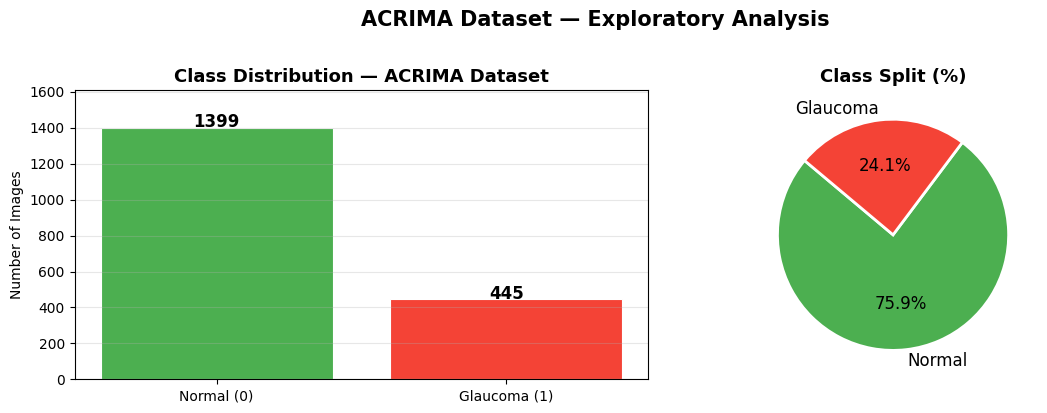

Total images  : 1844
Normal (0)    : 1399
Glaucoma (1)  : 445
Glaucoma ratio: 24.1%  ⚠️ Slight imbalance


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution bar chart
counts = meta['Glaucoma'].value_counts().sort_index()
labels = ['Normal (0)', 'Glaucoma (1)']
colors = ['#4CAF50', '#F44336']
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution — ACRIMA Dataset', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, max(counts.values) * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(
    counts.values,
    labels=['Normal', 'Glaucoma'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Split (%)', fontsize=13, fontweight='bold')

plt.suptitle('ACRIMA Dataset — Exploratory Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Total images  : {len(meta)}')
print(f'Normal (0)    : {(meta["Glaucoma"]==0).sum()}')
print(f'Glaucoma (1)  : {(meta["Glaucoma"]==1).sum()}')
imbalance = (meta['Glaucoma']==1).sum() / len(meta)
print(f'Glaucoma ratio: {imbalance:.1%}  {"⚠️ Slight imbalance" if abs(imbalance-0.5)>0.1 else "✅ Balanced"}')

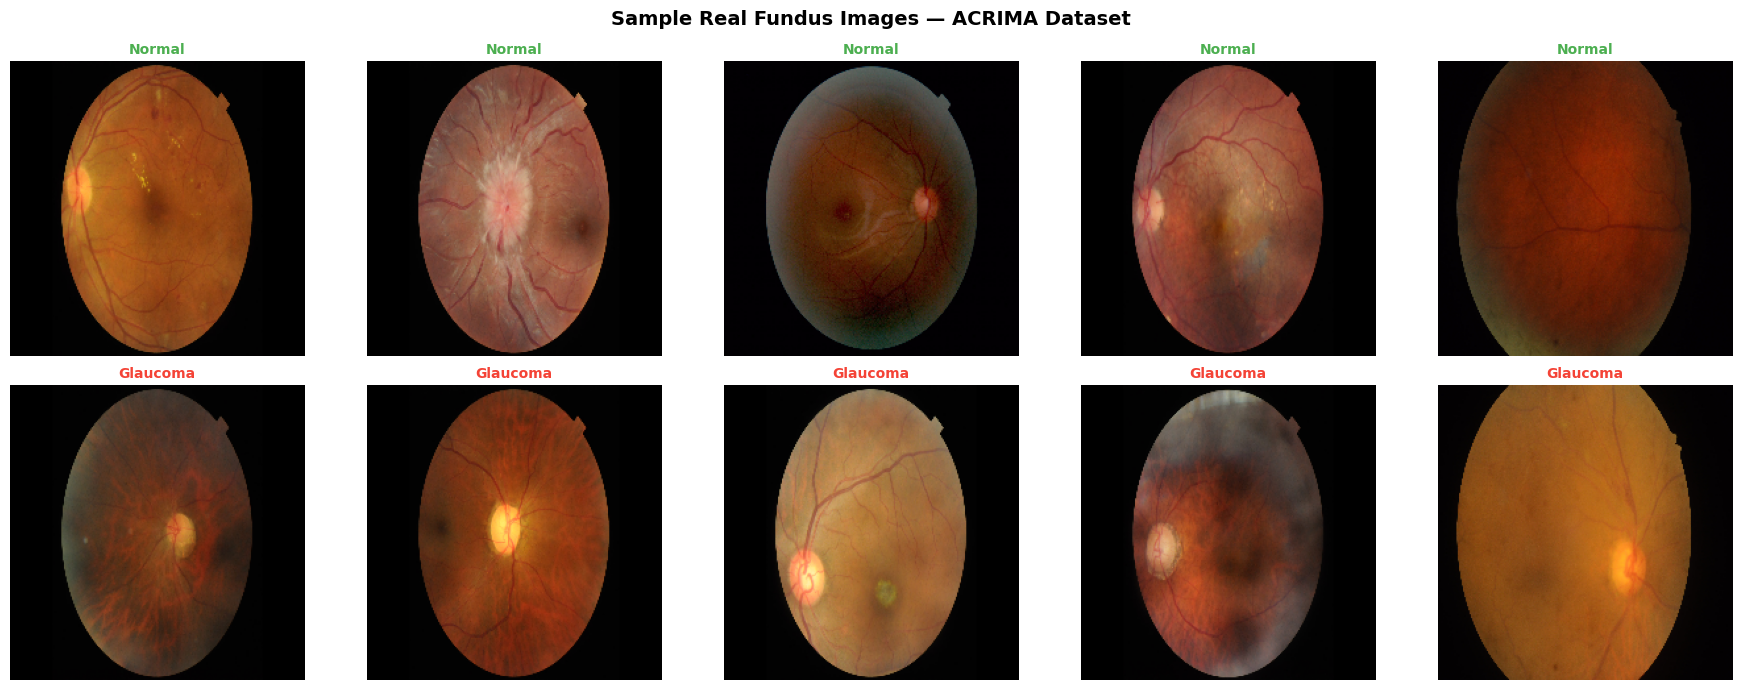

In [28]:
# Visualise sample real fundus images
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for row_idx, (lbl, title) in enumerate([(0, 'Normal'), (1, 'Glaucoma')]):
    samples = meta[meta['Glaucoma'] == lbl].sample(5, random_state=SEED)
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        img = cv2.imread(row['Path'])
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
        else:
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        axes[row_idx][col_idx].imshow(img)
        axes[row_idx][col_idx].set_title(f'{title}', fontsize=10, fontweight='bold',
                                          color='#F44336' if lbl==1 else '#4CAF50')
        axes[row_idx][col_idx].axis('off')

plt.suptitle('Sample Real Fundus Images — ACRIMA Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5️⃣ Image Preprocessing Pipeline
4-step pipeline: **Downscale → Localize → Enhance (CLAHE) → Resize**

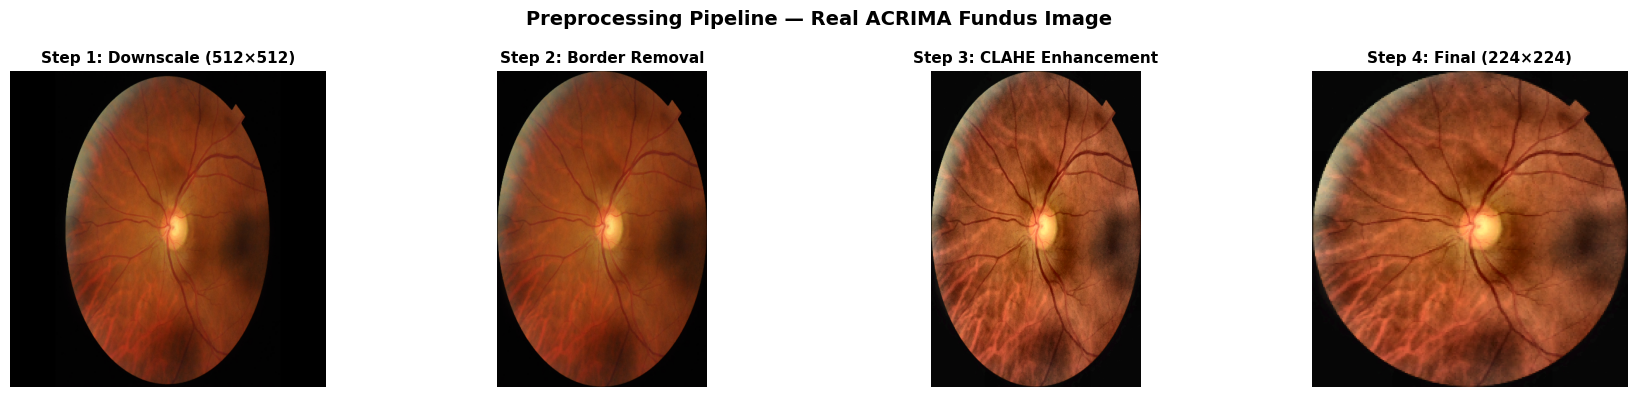

✅ Preprocessing functions defined


In [29]:
def apply_clahe(img_rgb):
    lab   = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def locate_eyeball(gray):
    blurred = cv2.GaussianBlur(gray, (9, 9), 2)
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT,
        dp=1, minDist=gray.shape[0] // 2,
        param1=100, param2=30,
        minRadius=gray.shape[0] // 4,
        maxRadius=gray.shape[0] // 2
    )
    if circles is not None:
        x, y, r = map(int, circles[0][0])
        pad = int(r * 0.05)
        x1 = max(0, x - r - pad); y1 = max(0, y - r - pad)
        x2 = min(gray.shape[1], x + r + pad); y2 = min(gray.shape[0], y + r + pad)
        return (x1, y1, x2, y2)
    return None


def remove_black_borders(img_rgb, thr=10):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    mask = gray > thr
    rows = np.any(mask, axis=1); cols = np.any(mask, axis=0)
    if rows.any():
        r1, r2 = np.where(rows)[0][[0, -1]]
        c1, c2 = np.where(cols)[0][[0, -1]]
        return img_rgb[r1:r2+1, c1:c2+1]
    return img_rgb


def preprocess_image(path, final_size=(224, 224)):
    img = cv2.imread(path)
    if img is None:
        return np.zeros((*final_size, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (512, 512))          # Step 1 – Downscale
    img = remove_black_borders(img)             # Step 2a – Remove borders
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    bbox = locate_eyeball(gray)                 # Step 2b – Locate eyeball
    if bbox:
        x1, y1, x2, y2 = bbox
        img = img[y1:y2, x1:x2]
    img = apply_clahe(img)                      # Step 3 – CLAHE
    img = cv2.resize(img, final_size)           # Step 4 – Final resize
    return (img / 255.0).astype(np.float32)


# Visualise preprocessing on a real ACRIMA image
sample_path = meta.sample(1, random_state=SEED).iloc[0]['Path']
raw = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)

step1 = cv2.resize(raw, (512, 512))
step2 = remove_black_borders(step1)
step3 = apply_clahe(step2)
step4 = cv2.resize(step3, (224, 224))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, img, title in zip(axes,
    [step1, step2, step3, step4],
    ['Step 1: Downscale (512×512)', 'Step 2: Border Removal',
     'Step 3: CLAHE Enhancement', 'Step 4: Final (224×224)']):
    ax.imshow(img)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Preprocessing Pipeline — Real ACRIMA Fundus Image', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ Preprocessing functions defined')

## 6️⃣ Build TF Dataset Pipeline

In [30]:
# Splits already defined above from pre-made CSVs — just confirm
print(f'✅ Using pre-defined dataset splits:')
print(f'   Train  : {len(train_df)} images (balanced: {dict(train_df["Glaucoma"].value_counts())})')
print(f'   Val    : {len(val_df)}  images ({dict(val_df["Glaucoma"].value_counts())})')
print(f'   Test   : {len(test_df)}  images ({dict(test_df["Glaucoma"].value_counts())})')

✅ Using pre-defined dataset splits:
   Train  : 564 images (balanced: {0: np.int64(282), 1: np.int64(282)})
   Val    : 640  images ({0: np.int64(568), 1: np.int64(72)})
   Test   : 640  images ({0: np.int64(549), 1: np.int64(91)})


In [31]:
# Preprocess and save to structured directory
PROCESSED_DIR = '/content/processed_images'
for split in ['train', 'val', 'test']:
    for lbl in ['normal', 'glaucoma']:
        os.makedirs(f'{PROCESSED_DIR}/{split}/{lbl}', exist_ok=True)

label_map = {0: 'normal', 1: 'glaucoma'}

print('⏳ Preprocessing images...')
total = len(train_df) + len(val_df) + len(test_df)
done  = 0

for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    for _, row in df.iterrows():
        lbl  = label_map[row['Glaucoma']]
        dest = f"{PROCESSED_DIR}/{split_name}/{lbl}/{row['Filename']}"
        if not os.path.exists(dest):
            img = preprocess_image(row['Path'])
            img_uint8 = (img * 255).astype(np.uint8)
            cv2.imwrite(dest, cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR))
        done += 1
        if done % 100 == 0:
            print(f'  Processed {done}/{total} images...')

print('✅ All images preprocessed and saved')
print(f'\nProcessed directory structure:')
for split in ['train', 'val', 'test']:
    for lbl in ['normal', 'glaucoma']:
        count = len(os.listdir(f'{PROCESSED_DIR}/{split}/{lbl}'))
        print(f'  {split}/{lbl}: {count} images')

⏳ Preprocessing images...
  Processed 100/1844 images...
  Processed 200/1844 images...
  Processed 300/1844 images...
  Processed 400/1844 images...
  Processed 500/1844 images...
  Processed 600/1844 images...
  Processed 700/1844 images...
  Processed 800/1844 images...
  Processed 900/1844 images...
  Processed 1000/1844 images...
  Processed 1100/1844 images...
  Processed 1200/1844 images...
  Processed 1300/1844 images...
  Processed 1400/1844 images...
  Processed 1500/1844 images...
  Processed 1600/1844 images...
  Processed 1700/1844 images...
  Processed 1800/1844 images...
✅ All images preprocessed and saved

Processed directory structure:
  train/normal: 282 images
  train/glaucoma: 282 images
  val/normal: 568 images
  val/glaucoma: 72 images
  test/normal: 549 images
  test/glaucoma: 91 images


In [32]:
# Data generators with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{PROCESSED_DIR}/train', target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    f'{PROCESSED_DIR}/val', target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    f'{PROCESSED_DIR}/test', target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print(f'Class indices : {train_gen.class_indices}')
print(f'Train batches : {len(train_gen)} | Val: {len(val_gen)} | Test: {len(test_gen)}')

Found 564 images belonging to 2 classes.
Found 640 images belonging to 2 classes.
Found 640 images belonging to 2 classes.
Class indices : {'glaucoma': 0, 'normal': 1}
Train batches : 36 | Val: 40 | Test: 40


## 7️⃣ Build Deep Learning Models

In [33]:
def build_model(backbone_fn, model_name, input_shape=(224,224,3),
                num_classes=2, unfreeze_last=20):
    backbone = backbone_fn(include_top=False, weights='imagenet', input_shape=input_shape)
    backbone.trainable = False
    for layer in backbone.layers[-unfreeze_last:]:
        layer.trainable = True

    inputs = tf.keras.Input(shape=input_shape, name='input_image')
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.4, name='drop1')(x)
    x = layers.Dense(256, activation='relu', name='fc2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return Model(inputs, outputs, name=model_name)


def compile_model(model, lr=LEARNING_RATE):
    model.compile(
        optimizer=RMSprop(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model


def get_callbacks(model_name):
    return [
        ModelCheckpoint(
            filepath=os.path.join(MODEL_DIR, f'{model_name}_best.h5'),
            monitor='val_accuracy', save_best_only=True, verbose=1
        ),
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-7, verbose=1)
    ]

print('✅ Model builder utilities defined')

✅ Model builder utilities defined


In [34]:
# VGG19
vgg19_model = build_model(VGG19, 'VGG19_Glaucoma', unfreeze_last=8)
vgg19_model = compile_model(vgg19_model)
vgg19_model.summary()
trainable = sum(np.prod(v.shape) for v in vgg19_model.trainable_weights)
non_trainable = sum(np.prod(v.shape) for v in vgg19_model.non_trainable_weights)
print(f'\nTrainable params     : {trainable:,}')
print(f'Non-trainable params : {non_trainable:,}')

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG19_Glaucoma"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,420,930 (77.90 MB)

 Trainable params: 14,554,370 (55.52 MB)

 Non-trainable params: 5,866,560 (22.38 MB)


Trainable params     : 14,554,370
Non-trainable params : 5,866,560


In [35]:
# ResNet101
resnet101_model = build_model(ResNet101, 'ResNet101_Glaucoma', unfreeze_last=20)
resnet101_model = compile_model(resnet101_model)
resnet101_model.summary(line_length=80)

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet101_Glaucoma"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ resnet101 (Functional)            │ (None, 7, 7, 2048)       │    42,658,176 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)      │ (None, 2048)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_1             │ (None, 2048)             │         8,192 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ fc1 (Dense)                       │ (None, 512)              │     1,049,088 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop1 (Dropout)                   │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ fc2 (Dense)                       │ (None, 256)              │       131,328 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop2 (Dropout)                   │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ predictions (Dense)               │ (None, 2)                │           514 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 43,847,298 (167.26 MB)

 Trainable params: 10,116,354 (38.59 MB)

 Non-trainable params: 33,730,944 (128.67 MB)

In [36]:
# MobileNetV2
mobilenet_model = build_model(MobileNetV2, 'MobileNetV2_Glaucoma', unfreeze_last=15)
mobilenet_model = compile_model(mobilenet_model)
mobilenet_model.summary(line_length=80)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Glaucoma"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224 (Functional) │ (None, 7, 7, 1280)       │     2,257,984 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)      │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_2             │ (None, 1280)             │         5,120 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ fc1 (Dense)                       │ (None, 512)              │       655,872 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop1 (Dropout)                   │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ fc2 (Dense)                       │ (None, 256)              │       131,328 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop2 (Dropout)                   │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ predictions (Dense)               │ (None, 2)                │           514 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 3,050,818 (11.64 MB)

 Trainable params: 1,830,274 (6.98 MB)

 Non-trainable params: 1,220,544 (4.66 MB)

## 8️⃣ Train All Three Models

In [37]:
def train_model(model, name, epochs=EPOCHS):
    print(f'\n{"="*60}')
    print(f'  Training {name}')
    print(f'{"="*60}')
    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        callbacks=get_callbacks(name),
        verbose=1
    )
    return history

history_vgg19     = train_model(vgg19_model,     'VGG19')
history_resnet    = train_model(resnet101_model,  'ResNet101')
history_mobilenet = train_model(mobilenet_model,  'MobileNetV2')


  Training VGG19
Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.5076 - auc: 0.5053 - loss: 0.7602 - precision: 0.5076 - recall: 0.5076
Epoch 1: val_accuracy improved from None to 0.88750, saving model to /content/drive/MyDrive/GlaucomaProject/models/VGG19_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/GlaucomaProject/models/VGG19_best.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 56s 998ms/step - accuracy: 0.4894 - auc: 0.4972 - loss: 0.7290 - precision: 0.4894 - recall: 0.4894 - val_accuracy: 0.8875 - val_auc: 0.8989 - val_loss: 0.3564 - val_precision: 0.8875 - val_recall: 0.8875 - learning_rate: 1.0000e-04
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.5622 - auc: 0.5713 - loss: 0.6860 - precision: 0.5622 - recall: 0.5622
Epoch 2: val_accuracy did not improve from 0.88750
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 557ms/step - accuracy: 0.5496 - auc: 0.5612 - loss: 0.6917 - precision: 0.5496 - recall: 0.5496 - val_accuracy: 0.8297 - val_auc: 0.8709 - val_loss: 0.5354 - val_precision: 0.8297 - val_recall: 0.8297 - learning_rate: 1.0000e-04
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.5303 - auc: 0.5420 - loss: 0.6938 - precision: 0.5303 - recall: 0.5303
Epoch 3: val_accuracy did not improve from 0.88750
36/36 ━━━


Epoch 1: finished saving model to /content/drive/MyDrive/GlaucomaProject/models/ResNet101_best.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.5337 - auc: 0.5643 - loss: 1.0044 - precision: 0.5337 - recall: 0.5337 - val_accuracy: 0.1125 - val_auc: 0.1116 - val_loss: 0.8524 - val_precision: 0.1125 - val_recall: 0.1125 - learning_rate: 1.0000e-04
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.4902 - auc: 0.4777 - loss: 1.0387 - precision: 0.4902 - recall: 0.4902
Epoch 2: val_accuracy did not improve from 0.11250
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 496ms/step - accuracy: 0.5000 - auc: 0.4892 - loss: 0.9946 - precision: 0.5000 - recall: 0.5000 - val_accuracy: 0.1125 - val_auc: 0.1189 - val_loss: 0.7634 - val_precision: 0.1125 - val_recall: 0.1125 - learning_rate: 1.0000e-04
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.5292 - auc: 0.5376 - loss: 0.8715 - precision: 0.5292 - recall: 0.5292
Epoch 3: val_accuracy improved from 0.11250 to 0.88750, sav


Epoch 3: finished saving model to /content/drive/MyDrive/GlaucomaProject/models/ResNet101_best.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 634ms/step - accuracy: 0.5372 - auc: 0.5442 - loss: 0.8730 - precision: 0.5372 - recall: 0.5372 - val_accuracy: 0.8875 - val_auc: 0.8917 - val_loss: 0.6448 - val_precision: 0.8875 - val_recall: 0.8875 - learning_rate: 1.0000e-04
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.5174 - auc: 0.5280 - loss: 0.8837 - precision: 0.5174 - recall: 0.5174
Epoch 4: val_accuracy did not improve from 0.88750
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 530ms/step - accuracy: 0.5018 - auc: 0.5085 - loss: 0.8733 - precision: 0.5018 - recall: 0.5018 - val_accuracy: 0.8719 - val_auc: 0.9074 - val_loss: 0.6677 - val_precision: 0.8719 - val_recall: 0.8719 - learning_rate: 1.0000e-04
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.4626 - auc: 0.4636 - loss: 0.8463 - precision: 0.4626 - recall: 0.4626
Epoch 5: val_accuracy did not improve from 0.88750
36/36


Epoch 1: finished saving model to /content/drive/MyDrive/GlaucomaProject/models/MobileNetV2_best.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5461 - auc: 0.5765 - loss: 0.9128 - precision: 0.5461 - recall: 0.5461 - val_accuracy: 0.8000 - val_auc: 0.8498 - val_loss: 0.5005 - val_precision: 0.8000 - val_recall: 0.8000 - learning_rate: 1.0000e-04
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.6410 - auc: 0.6877 - loss: 0.7784 - precision: 0.6410 - recall: 0.6410
Epoch 2: val_accuracy did not improve from 0.80000
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 339ms/step - accuracy: 0.6365 - auc: 0.6922 - loss: 0.7738 - precision: 0.6365 - recall: 0.6365 - val_accuracy: 0.7844 - val_auc: 0.8379 - val_loss: 0.5069 - val_precision: 0.7844 - val_recall: 0.7844 - learning_rate: 1.0000e-04
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.6794 - auc: 0.7215 - loss: 0.7417 - precision: 0.6794 - recall: 0.6794
Epoch 3: val_accuracy did not improve from 0.80000
36/36 

## 9️⃣ Ensemble Integration & Evaluation

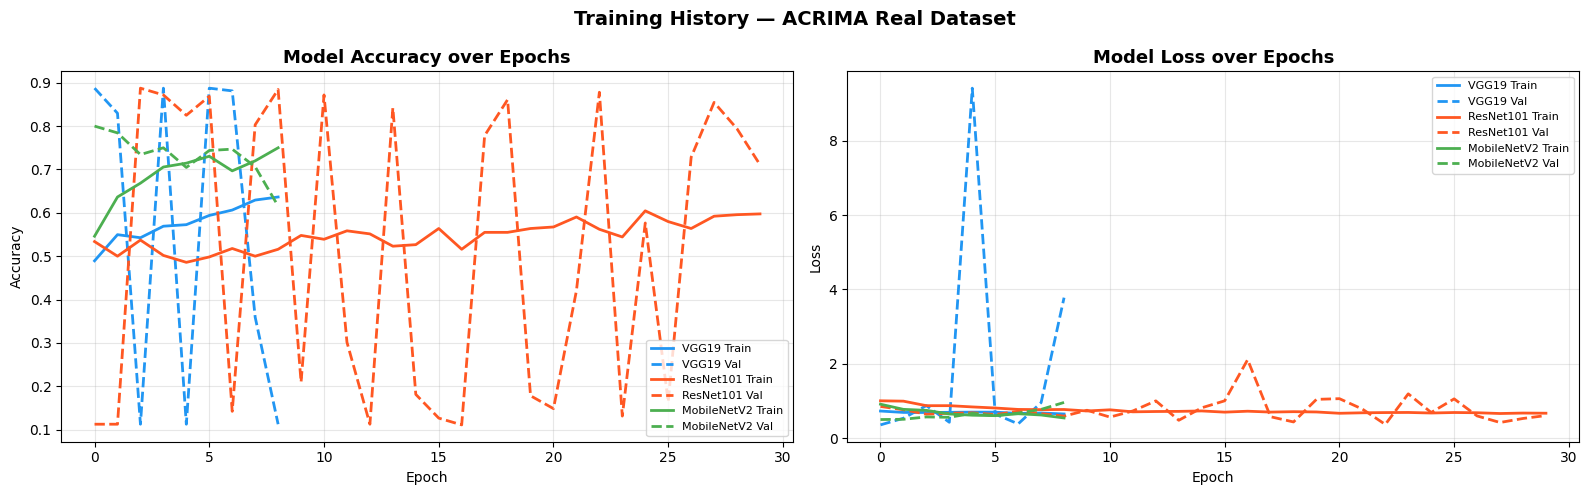

In [38]:
# Training history plots
def plot_training_history(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = ['#2196F3', '#FF5722', '#4CAF50']
    for hist, name, color in zip(histories, names, colors):
        axes[0].plot(hist.history['accuracy'],    color=color, label=f'{name} Train', linewidth=2)
        axes[0].plot(hist.history['val_accuracy'], color=color, label=f'{name} Val',  linestyle='--', linewidth=2)
        axes[1].plot(hist.history['loss'],         color=color, label=f'{name} Train', linewidth=2)
        axes[1].plot(hist.history['val_loss'],     color=color, label=f'{name} Val',  linestyle='--', linewidth=2)
    for ax, title, ylabel in zip(axes,
                                   ['Model Accuracy over Epochs', 'Model Loss over Epochs'],
                                   ['Accuracy', 'Loss']):
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle('Training History — ACRIMA Real Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

plot_training_history(
    [history_vgg19, history_resnet, history_mobilenet],
    ['VGG19', 'ResNet101', 'MobileNetV2']
)

In [39]:
# Per-model evaluation on test set
def evaluate_model(model, name, generator):
    generator.reset()
    y_pred_proba = model.predict(generator, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    y_true       = generator.classes
    y_pred       = y_pred[:len(y_true)]
    y_pred_proba = y_pred_proba[:len(y_true)]
    auc = roc_auc_score(y_true, y_pred_proba[:, 1])
    print(f'\n{"="*50}\n  {name} — Test Results\n{"="*50}')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Glaucoma']))
    print(f'  AUC-ROC: {auc:.4f}')
    return y_true, y_pred, y_pred_proba

vgg_true,  vgg_pred,  vgg_proba  = evaluate_model(vgg19_model,    'VGG19',       test_gen)
res_true,  res_pred,  res_proba  = evaluate_model(resnet101_model, 'ResNet101',   test_gen)
mob_true,  mob_pred,  mob_proba  = evaluate_model(mobilenet_model, 'MobileNetV2', test_gen)


  VGG19 — Test Results
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00        91
    Glaucoma       0.86      1.00      0.92       549

    accuracy                           0.86       640
   macro avg       0.43      0.50      0.46       640
weighted avg       0.74      0.86      0.79       640

  AUC-ROC: 0.4451

  ResNet101 — Test Results
              precision    recall  f1-score   support

      Normal       0.20      0.01      0.02        91
    Glaucoma       0.86      0.99      0.92       549

    accuracy                           0.85       640
   macro avg       0.53      0.50      0.47       640
weighted avg       0.76      0.85      0.79       640

  AUC-ROC: 0.5359

  MobileNetV2 — Test Results
              precision    recall  f1-score   support

      Normal       0.25      0.27      0.26        91
    Glaucoma       0.88      0.87      0.87       549

    accuracy                           0.78       640
   macro a

In [40]:
# Ensemble: soft voting (average probabilities)
ensemble_proba = (vgg_proba + res_proba + mob_proba) / 3.0
ensemble_pred  = np.argmax(ensemble_proba, axis=1)

print('\n' + '='*50)
print('  ENSEMBLE (VGG19 + ResNet101 + MobileNetV2)')
print('='*50)
print(classification_report(vgg_true, ensemble_pred, target_names=['Normal', 'Glaucoma']))
ens_auc = roc_auc_score(vgg_true, ensemble_proba[:, 1])
print(f'  Ensemble AUC-ROC: {ens_auc:.4f}')


  ENSEMBLE (VGG19 + ResNet101 + MobileNetV2)
              precision    recall  f1-score   support

      Normal       1.00      0.01      0.02        91
    Glaucoma       0.86      1.00      0.92       549

    accuracy                           0.86       640
   macro avg       0.93      0.51      0.47       640
weighted avg       0.88      0.86      0.80       640

  Ensemble AUC-ROC: 0.5653


## 🔟 Results & Visualisation

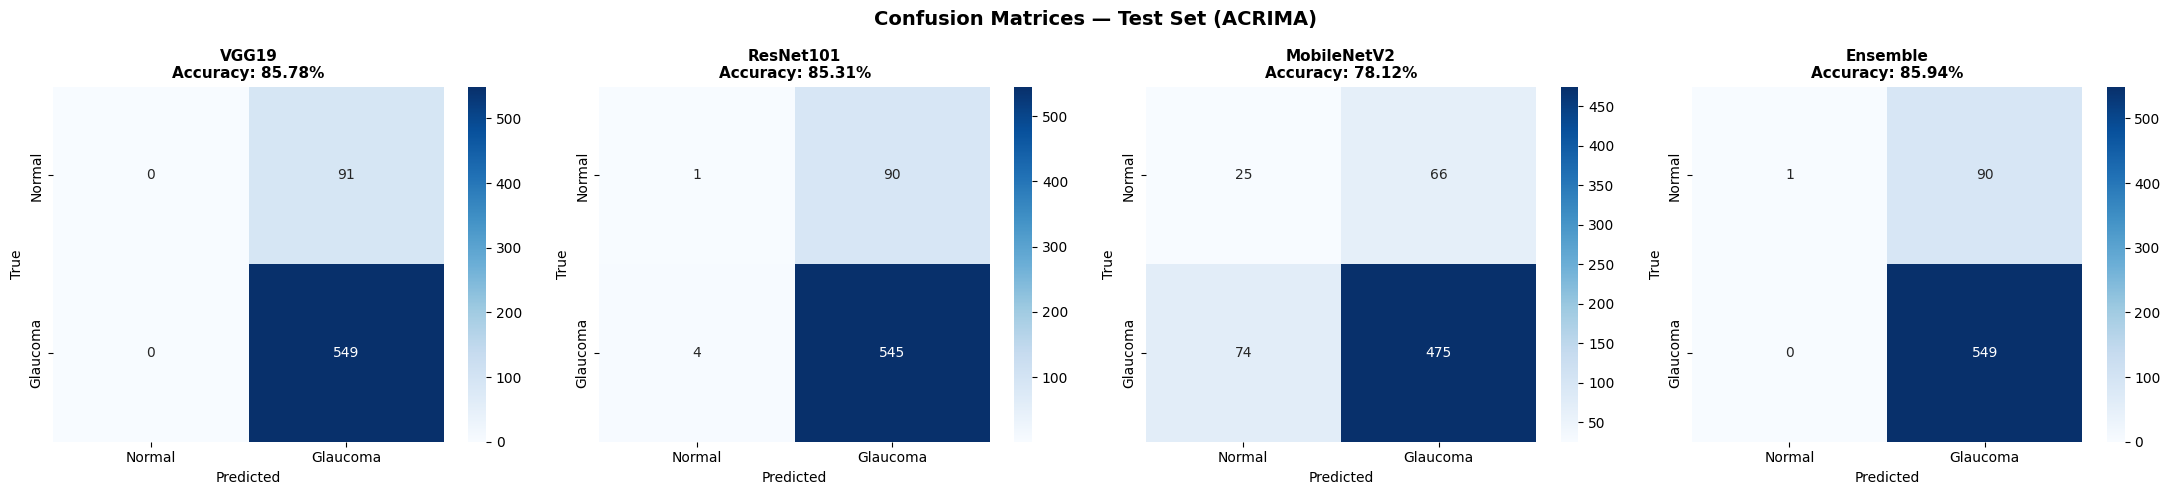

In [41]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
model_results = [
    ('VGG19',       vgg_true, vgg_pred),
    ('ResNet101',   res_true, res_pred),
    ('MobileNetV2', mob_true, mob_pred),
    ('Ensemble',    vgg_true, ensemble_pred),
]
for ax, (name, y_t, y_p) in zip(axes, model_results):
    cm = confusion_matrix(y_t, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Glaucoma'],
                yticklabels=['Normal', 'Glaucoma'])
    acc = np.trace(cm) / cm.sum()
    ax.set_title(f'{name}\nAccuracy: {acc:.2%}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrices — Test Set (ACRIMA)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

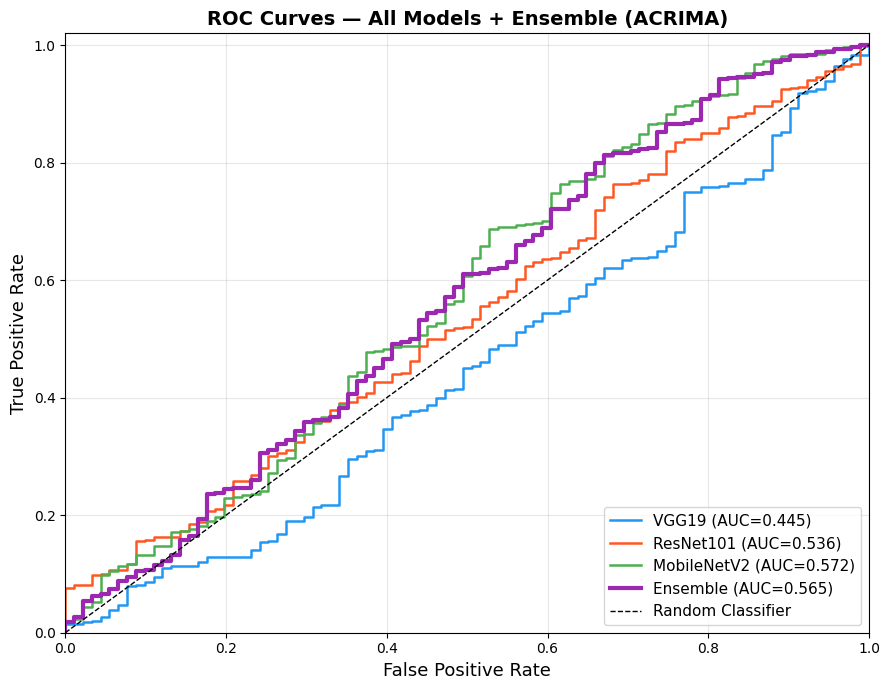

In [42]:
# ROC Curves
fig, ax = plt.subplots(figsize=(9, 7))
roc_data = [
    ('VGG19',       vgg_true, vgg_proba[:,1],     '#2196F3'),
    ('ResNet101',   res_true, res_proba[:,1],     '#FF5722'),
    ('MobileNetV2', mob_true, mob_proba[:,1],     '#4CAF50'),
    ('Ensemble',    vgg_true, ensemble_proba[:,1], '#9C27B0'),
]
for name, y_t, y_s, color in roc_data:
    fpr, tpr, _ = roc_curve(y_t, y_s)
    auc = roc_auc_score(y_t, y_s)
    lw  = 3 if name == 'Ensemble' else 1.8
    ax.plot(fpr, tpr, color=color, lw=lw, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — All Models + Ensemble (ACRIMA)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

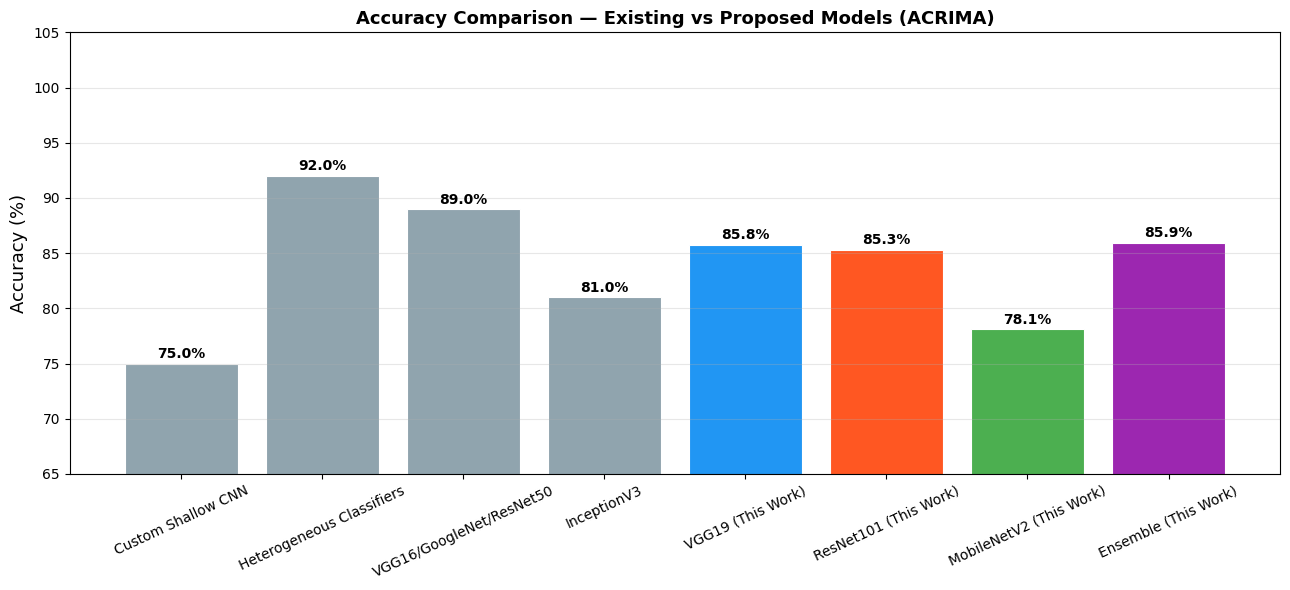

In [43]:
# Accuracy comparison bar chart (vs literature)
results = {
    'Custom Shallow CNN':        0.75,
    'Heterogeneous Classifiers': 0.92,
    'VGG16/GoogleNet/ResNet50':  0.8896,
    'InceptionV3':               0.81,
    'VGG19 (This Work)':         accuracy_score(vgg_true, vgg_pred),
    'ResNet101 (This Work)':     accuracy_score(res_true, res_pred),
    'MobileNetV2 (This Work)':   accuracy_score(mob_true, mob_pred),
    'Ensemble (This Work)':      accuracy_score(vgg_true, ensemble_pred),
}
colors = ['#90A4AE']*4 + ['#2196F3','#FF5722','#4CAF50','#9C27B0']
fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(results.keys(), [v*100 for v in results.values()],
               color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
            f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim([65, 105])
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Accuracy Comparison — Existing vs Proposed Models (ACRIMA)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [44]:
# Final Summary Table
summary_rows = []
for name, y_t, y_p, y_s in [
    ('VGG19',       vgg_true, vgg_pred,      vgg_proba[:,1]),
    ('ResNet101',   res_true, res_pred,      res_proba[:,1]),
    ('MobileNetV2', mob_true, mob_pred,      mob_proba[:,1]),
    ('Ensemble',    vgg_true, ensemble_pred, ensemble_proba[:,1]),
]:
    summary_rows.append({
        'Model':     name,
        'Accuracy':  f"{accuracy_score(y_t, y_p)*100:.2f}%",
        'Precision': f"{precision_score(y_t, y_p, average='weighted')*100:.2f}%",
        'Recall':    f"{recall_score(y_t, y_p, average='weighted')*100:.2f}%",
        'F1-Score':  f"{f1_score(y_t, y_p, average='weighted')*100:.2f}%",
        'AUC-ROC':   f"{roc_auc_score(y_t, y_s):.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
print('\n📊 FINAL RESULTS SUMMARY — ACRIMA REAL DATASET')
print('='*75)
print(summary_df.to_string(index=False))
print('='*75)
summary_df


📊 FINAL RESULTS SUMMARY — ACRIMA REAL DATASET
      Model Accuracy Precision Recall F1-Score AUC-ROC
      VGG19   85.78%    73.58% 85.78%   79.22%  0.4451
  ResNet101   85.31%    76.47% 85.31%   79.27%  0.5359
MobileNetV2   78.12%    78.91% 78.12%   78.51%  0.5721
   Ensemble   85.94%    87.92% 85.94%   79.59%  0.5653


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,VGG19,85.78%,73.58%,85.78%,79.22%,0.4451
1,ResNet101,85.31%,76.47%,85.31%,79.27%,0.5359
2,MobileNetV2,78.12%,78.91%,78.12%,78.51%,0.5721
3,Ensemble,85.94%,87.92%,85.94%,79.59%,0.5653


## 1️⃣1️⃣ Save Models & Export

In [45]:
vgg19_model.save(os.path.join(MODEL_DIR, 'vgg19_glaucoma_acrima.h5'))
resnet101_model.save(os.path.join(MODEL_DIR, 'resnet101_glaucoma_acrima.h5'))
mobilenet_model.save(os.path.join(MODEL_DIR, 'mobilenet_glaucoma_acrima.h5'))
summary_df.to_csv(os.path.join(MODEL_DIR, 'results_summary_acrima.csv'), index=False)

print('✅ Models saved to Google Drive:')
print(f'   {MODEL_DIR}')
print('   - vgg19_glaucoma_acrima.h5')
print('   - resnet101_glaucoma_acrima.h5')
print('   - mobilenet_glaucoma_acrima.h5')
print('   - results_summary_acrima.csv')

✅ Models saved to Google Drive:
   /content/drive/MyDrive/GlaucomaProject/models
   - vgg19_glaucoma_acrima.h5
   - resnet101_glaucoma_acrima.h5
   - mobilenet_glaucoma_acrima.h5
   - results_summary_acrima.csv


## 1️⃣2️⃣ Single-Image Inference Demo

🏷️  True label: Normal


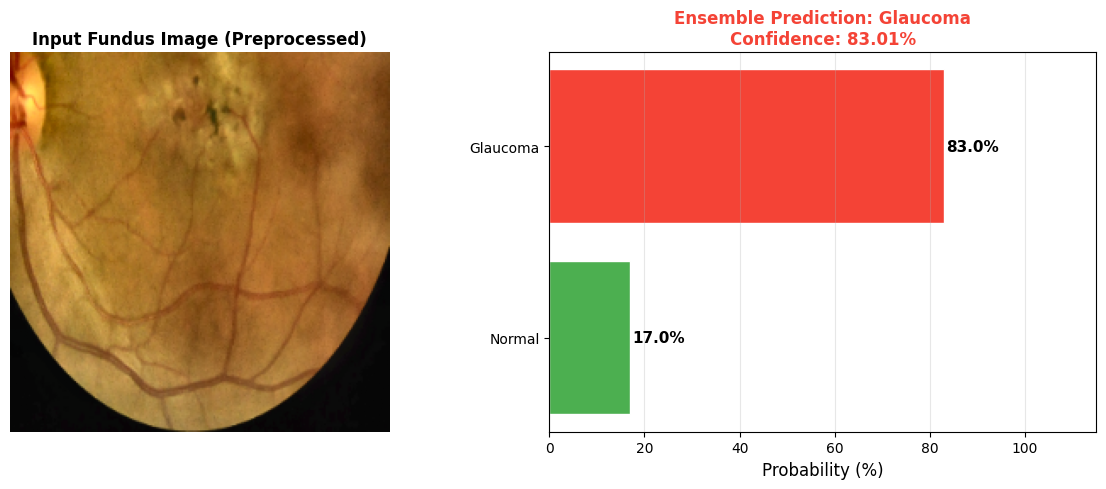


🔍 Prediction  : Glaucoma
   Confidence  : 83.01%
   VGG19       : Normal=0.072  Glaucoma=0.928
   ResNet101   : Normal=0.129  Glaucoma=0.871
   MobileNetV2 : Normal=0.308  Glaucoma=0.692


('Glaucoma', np.float32(0.83010286))

In [46]:
def predict_single_image(image_path, models, class_names=['Normal', 'Glaucoma']):
    img = preprocess_image(image_path)
    img_batch = np.expand_dims(img, axis=0)

    probas = [m.predict(img_batch, verbose=0)[0] for m in models]
    avg_proba = np.mean(probas, axis=0)
    predicted_class = class_names[np.argmax(avg_proba)]
    confidence = np.max(avg_proba)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img)
    axes[0].set_title('Input Fundus Image (Preprocessed)', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    bar_colors = ['#4CAF50' if c == 'Normal' else '#F44336' for c in class_names]
    axes[1].barh(class_names, avg_proba * 100, color=bar_colors, edgecolor='white')
    for i, (name, p) in enumerate(zip(class_names, avg_proba)):
        axes[1].text(p*100+0.5, i, f'{p*100:.1f}%', va='center',
                     fontsize=11, fontweight='bold')
    axes[1].set_xlim([0, 115])
    axes[1].set_xlabel('Probability (%)', fontsize=12)
    pred_color = '#F44336' if predicted_class == 'Glaucoma' else '#4CAF50'
    axes[1].set_title(
        f'Ensemble Prediction: {predicted_class}\nConfidence: {confidence:.2%}',
        fontsize=12, fontweight='bold', color=pred_color
    )
    axes[1].grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f'\n🔍 Prediction  : {predicted_class}')
    print(f'   Confidence  : {confidence:.2%}')
    for m_name, p in zip(['VGG19', 'ResNet101', 'MobileNetV2'], probas):
        print(f'   {m_name:12s}: Normal={p[0]:.3f}  Glaucoma={p[1]:.3f}')
    return predicted_class, confidence


# Demo: predict on a random test image
sample = test_df.sample(1, random_state=99).iloc[0]
true_label = 'Glaucoma' if sample['Glaucoma'] == 1 else 'Normal'
print(f'🏷️  True label: {true_label}')
predict_single_image(
    sample['Path'],
    [vgg19_model, resnet101_model, mobilenet_model]
)